<Axes: xlabel='timeline'>

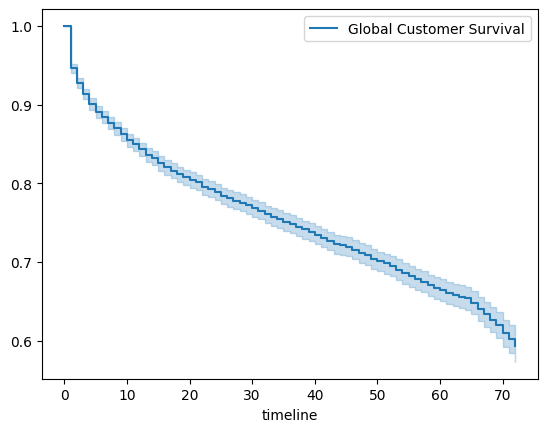

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

df = pd.read_csv('../Data/Telco-Customer-Churn.csv')

df['Event'] = df['Churn'].apply(lambda x:1 if x == 'Yes' else 0)
kmf = KaplanMeierFitter()
kmf.fit(durations = df['tenure'] , event_observed = df['Event'], label = 'Global Customer Survival')
kmf.plot_survival_function()

### Segment1: Month-to-Month contracts

In [15]:
month_to_month = df[df['Contract'] == 'Month-to-month']


### Segment2: Two year contracts

In [16]:
two_year = df[df['Contract'] == 'Two year']

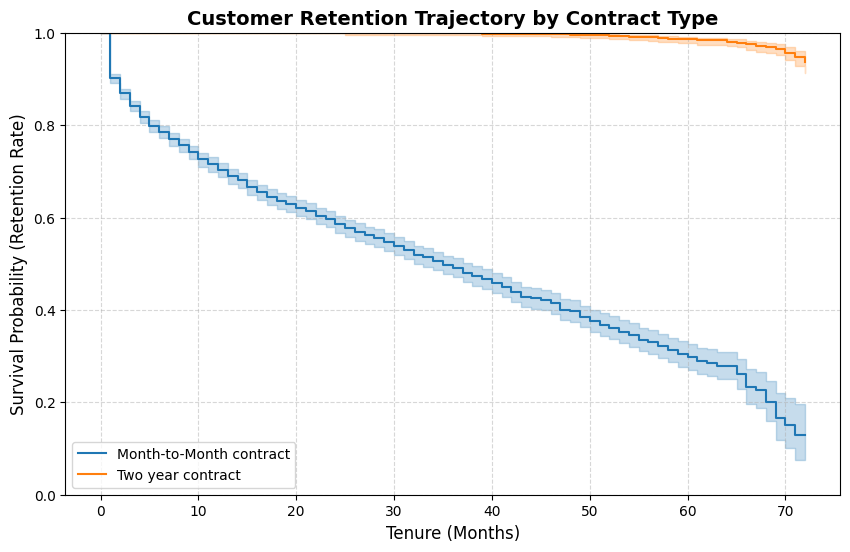

In [17]:
kmf_monthly = KaplanMeierFitter()
kmf_2year = KaplanMeierFitter()

plt.figure(figsize=(10,6))

kmf_monthly.fit(month_to_month['tenure'] , month_to_month['Event'] , label='Month-to-Month contract')
ax= kmf_monthly.plot_survival_function()

kmf_2year.fit(two_year['tenure'] , two_year['Event'] , label='Two year contract')
kmf_2year.plot_survival_function(ax=ax)

plt.title('Customer Retention Trajectory by Contract Type', fontsize=14, weight='bold')
plt.xlabel('Tenure (Months)', fontsize=12)
plt.ylabel('Survival Probability (Retention Rate)', fontsize=12)
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


## Data Preparation for Survival Models

In [19]:
# handle TotalCharges column robustly
# replace empty/whitespace-only strings with NA, then coerce to numeric
df['TotalCharges'] = df['TotalCharges'].replace(r'^\s*$', pd.NA, regex=True)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# fill missing values with the median
if df['TotalCharges'].isna().any():
    df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# prepare model dataframe
df_model = df.drop(columns=['customerID', 'Churn'])

# one-hot encode categorical vars; keep integers for encoded dummies
df_encoded = pd.get_dummies(df_model, drop_first=True, dtype=int)

print(f"Data ready for modeling! Shape: {df_encoded.shape}")


Data ready for modeling! Shape: (7043, 31)


### Training the Cox Proportional Hazards Model

In [25]:
from lifelines import CoxPHFitter
cph = CoxPHFitter(penalizer=0.1)
# add L2 penalization to mitigate collinearity / singular matrix issues
cph.fit(df_encoded, duration_col='tenure', event_col='Event')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 7043 total observations, 5174 right-censored observations>
             duration col = 'tenure'
                event col = 'Event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 7043
number of events observed = 1869
   partial log-likelihood = -13928.00
         time fit was run = 2026-06-22 18:34:03 UTC

---
                                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                              
SeniorCitizen                          0.05      1.05      0.05           -0.05            0.14                0.95                1.15
MonthlyCharges                         0.00      1.00      0.00            0.00            0.01                1.00                1.01
TotalCharges                          -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
gender_Male                           -0.03      0.97      0.04           -0.11            0.04                0.89                1.04
Partner_Yes                           -0.31      0.73      0.04           -0.39           -0.23                0.67                0.80
Dependents_Yes                        -0.15      0.86      0.05           -0.25           -0.05                0.78                0.95
PhoneService_Yes                       0.11      1.12      0.10           -0.08            0.31                0.92                1.36
MultipleLines_No phone service        -0.11      0.90      0.10           -0.31            0.08                0.74                1.09
MultipleLines_Yes                     -0.15      0.86      0.04           -0.24           -0.07                0.79                0.94
InternetService_Fiber optic            0.47      1.60      0.05            0.37            0.58                1.45                1.78
InternetService_No                    -0.22      0.80      0.09           -0.39           -0.06                0.68                0.95
OnlineSecurity_No internet service    -0.22      0.80      0.09           -0.39           -0.06                0.68                0.95
OnlineSecurity_Yes                    -0.43      0.65      0.05           -0.52           -0.33                0.59                0.72
OnlineBackup_No internet service      -0.22      0.80      0.09           -0.39           -0.06                0.68                0.95
OnlineBackup_Yes                      -0.31      0.73      0.04           -0.40           -0.22                0.67                0.80
DeviceProtection_No internet service  -0.22      0.80      0.09           -0.39           -0.06                0.68                0.95
DeviceProtection_Yes                  -0.18      0.83      0.05           -0.27           -0.09                0.76                0.91
TechSupport_No internet service       -0.22      0.80      0.09           -0.39           -0.06                0.68                0.95
TechSupport_Yes                       -0.34      0.71      0.05           -0.43           -0.24                0.65                0.79
StreamingTV_No internet service       -0.22      0.80      0.09           -0.39           -0.06                0.68                0.95
StreamingTV_Yes                        0.04      1.04      0.04           -0.05            0.12                0.95                1.13
StreamingMovies_No internet service   -0.22      0.80      0.09           -0.39           -0.06                0.68                0.95
StreamingMovies_Yes                    0.01      1.01      0.04           -0.08            0.10                0.92                1.10
Contract_One year                     -0.67      0.51      0.06           -0.78           -0.55                0.46                0.58
Contract_Two year                  

## Presenting the Results: The Hazard Ratio Plot

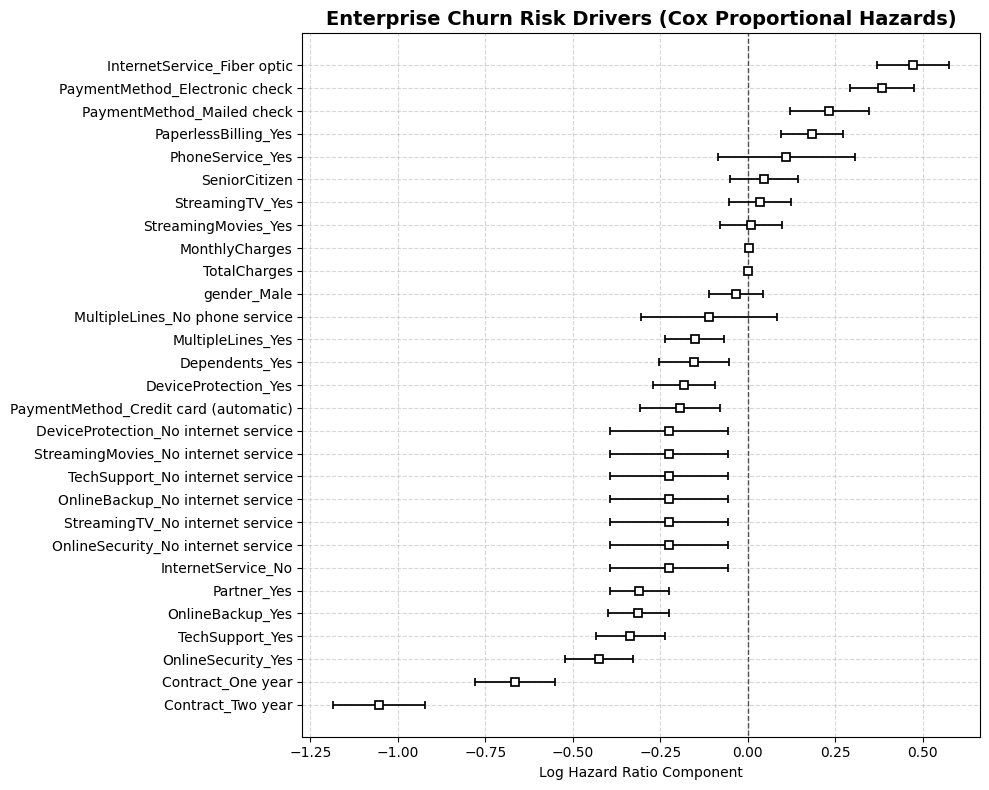

In [26]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(10,8))
cph.plot()
plt.title('Enterprise Churn Risk Drivers (Cox Proportional Hazards)', fontsize=14, weight='bold')
plt.xlabel('Log Hazard Ratio Component')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('cox_hazards_drivers.png', dpi=300)
plt.show()

### Predicting the exact individual survival timeline

In [27]:
individual_profile = df_encoded.drop(columns=['tenure', 'Event']).iloc[0:1]

print("Predicting survival trajectory for Customer ID 0...")

Predicting survival trajectory for Customer ID 0...


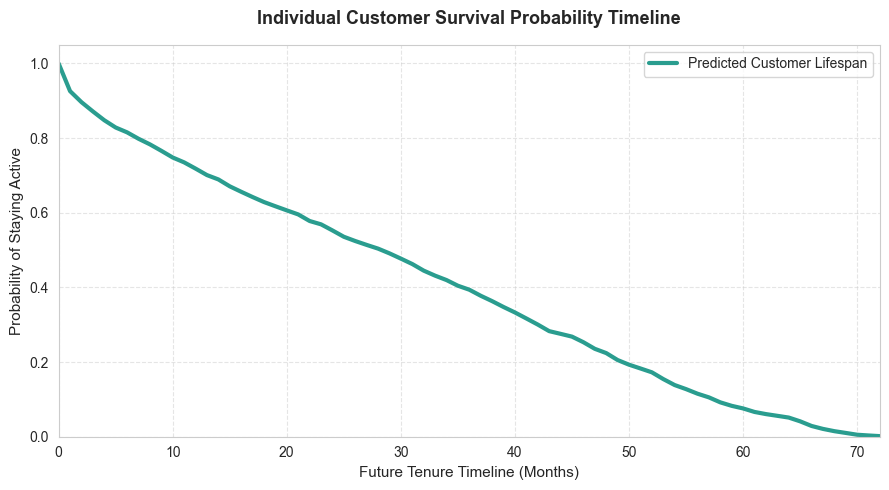

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Generate the individual survival curve dataframe
individual_survival_curve = cph.predict_survival_function(individual_profile)

# Plotting the individual trajectory
plt.figure(figsize=(9, 5))
sns.set_style("whitegrid")

plt.plot(
    individual_survival_curve.index, 
    individual_survival_curve.iloc[:, 0], 
    color='#2A9D8F', 
    linewidth=3, 
    label='Predicted Customer Lifespan'
)

# Style and Details
plt.title('Individual Customer Survival Probability Timeline', fontsize=13, weight='bold', pad=15)
plt.xlabel('Future Tenure Timeline (Months)', fontsize=11)
plt.ylabel('Probability of Staying Active', fontsize=11)
plt.xlim(0, 72)
plt.ylim(0, 1.05)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()

# Save for portfolio presentation
plt.savefig('individual_customer_prediction.png', dpi=300)
plt.show()

In [31]:
print(f"📊 Business Actionable Metric:")
print(f"This specific customer profile has an expected remaining lifespan of {median_lifespan} months before high-risk churn dropoff occurs.")

📊 Business Actionable Metric:
This specific customer profile has an expected remaining lifespan of 29.0 months before high-risk churn dropoff occurs.
